In [3]:
import sys
import sklearn

print("Python version:", sys.version)
print("Scikit-Learn version:", sklearn.__version__)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
Scikit-Learn version: 1.7.2


## 1. Get Data

### Problem Definition

This project uses the "Impact of Social Media on Life" dataset, it contains information on students' social media usage, sleep patterns, perceived stress, demographic characteristics, and academic outcomes.

The dataset contains 4,500 student records and 16 original variables. We set the prediction target as **Mental_Health_Index**. We want to build a regression model that predicts students' Mental Health Index based on their social media usage, sleep-related characteristics, stress and other available predictors.

In [4]:
import pandas as pd

student_data = pd.read_csv("Social_media_impact_on_life.csv")
student_data.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [5]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   object 
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   object 
 3   Academic_Level               4500 non-null   object 
 4   Primary_Platform             4500 non-null   object 
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   object 
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   object 
 12  Perceived_Stress_Score       4454 non-null   float64
 13  Mental_Health_Inde

In [6]:
student_data["Overall_Impact"].value_counts()

Overall_Impact
Beneficial    3681
Neutral        654
Negative       165
Name: count, dtype: int64

In [7]:
student_data.describe()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4454.000000,4500.000000,4415.000000
mean,18.703333,5.295933,1.796844,6.701333,2.472000,13.512124,79.873111,3.429282
std,1.981182,2.604497,0.699245,1.189998,1.030484,7.072859,12.876044,0.392662
min,15.000000,0.900000,0.000000,3.000000,1.000000,0.000000,32.000000,1.900000
25%,17.000000,3.400000,1.300000,6.000000,2.000000,9.000000,72.000000,3.200000
50%,19.000000,4.700000,1.800000,6.800000,3.000000,13.000000,82.000000,3.460000
75%,20.000000,6.600000,2.300000,7.500000,3.000000,18.000000,89.000000,3.720000
max,26.000000,14.000000,4.500000,10.500000,5.000000,40.000000,98.000000,4.000000


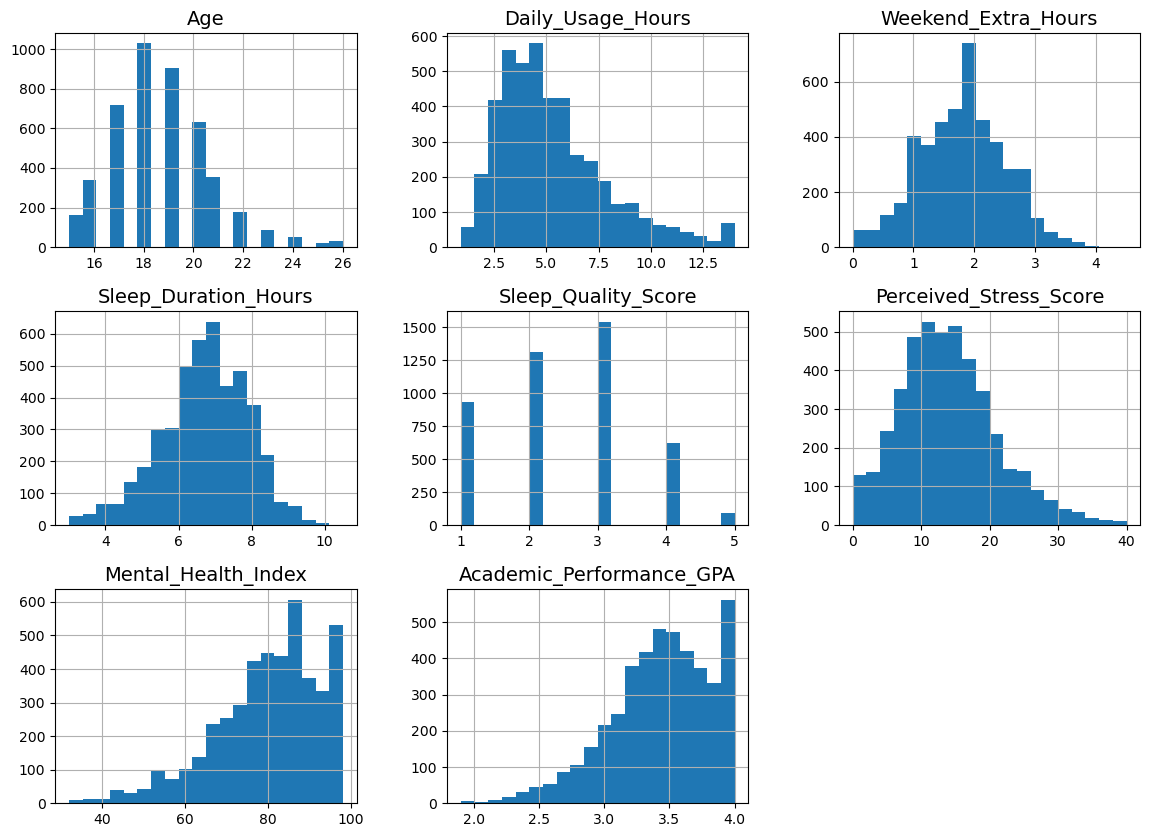

In [8]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

student_data.hist(bins=20, figsize=(14, 10))
plt.show()

## 2. Create a Test Set

In [9]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    student_data,
    test_size=0.2,
    stratify=student_data["Academic_Level"],
    random_state=42
)


In [10]:
train_set.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         34
Mental_Health_Index             0
Academic_Performance_GPA       75
Overall_Impact                  0
dtype: int64

In [11]:
test_set.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         12
Mental_Health_Index             0
Academic_Performance_GPA       10
Overall_Impact                  0
dtype: int64

In [12]:
len(train_set)

3600

In [13]:
len(test_set)

900

In [14]:
student_data["Academic_Level"].value_counts(normalize=True)

Academic_Level
Undergraduate    0.617111
High School      0.328222
Postgraduate     0.054667
Name: proportion, dtype: float64

In [15]:
train_set["Academic_Level"].value_counts(normalize=True)

Academic_Level
Undergraduate    0.617222
High School      0.328056
Postgraduate     0.054722
Name: proportion, dtype: float64

In [16]:
test_set["Academic_Level"].value_counts(normalize=True)

Academic_Level
Undergraduate    0.616667
High School      0.328889
Postgraduate     0.054444
Name: proportion, dtype: float64

## 3. Discover and Visualize the Data to Gain Insights

In [17]:
student_train = train_set.copy()

### Looking for Correlations

In [18]:
corr_matrix = student_train.corr(numeric_only=True)

In [19]:
# Mental health
corr_matrix["Mental_Health_Index"].sort_values(ascending=False)

Mental_Health_Index         1.000000
Sleep_Duration_Hours        0.780636
Academic_Performance_GPA    0.668317
Sleep_Quality_Score         0.662984
Age                         0.032579
Weekend_Extra_Hours         0.008177
Late_Night_Usage           -0.311907
Perceived_Stress_Score     -0.775313
Daily_Usage_Hours          -0.854041
Name: Mental_Health_Index, dtype: float64

In [20]:
# Academic Performance
corr_matrix["Academic_Performance_GPA"].sort_values(ascending=False)

Academic_Performance_GPA    1.000000
Mental_Health_Index         0.668317
Sleep_Duration_Hours        0.605690
Sleep_Quality_Score         0.531593
Age                         0.040135
Weekend_Extra_Hours         0.011921
Late_Night_Usage           -0.265034
Perceived_Stress_Score     -0.652347
Daily_Usage_Hours          -0.712646
Name: Academic_Performance_GPA, dtype: float64

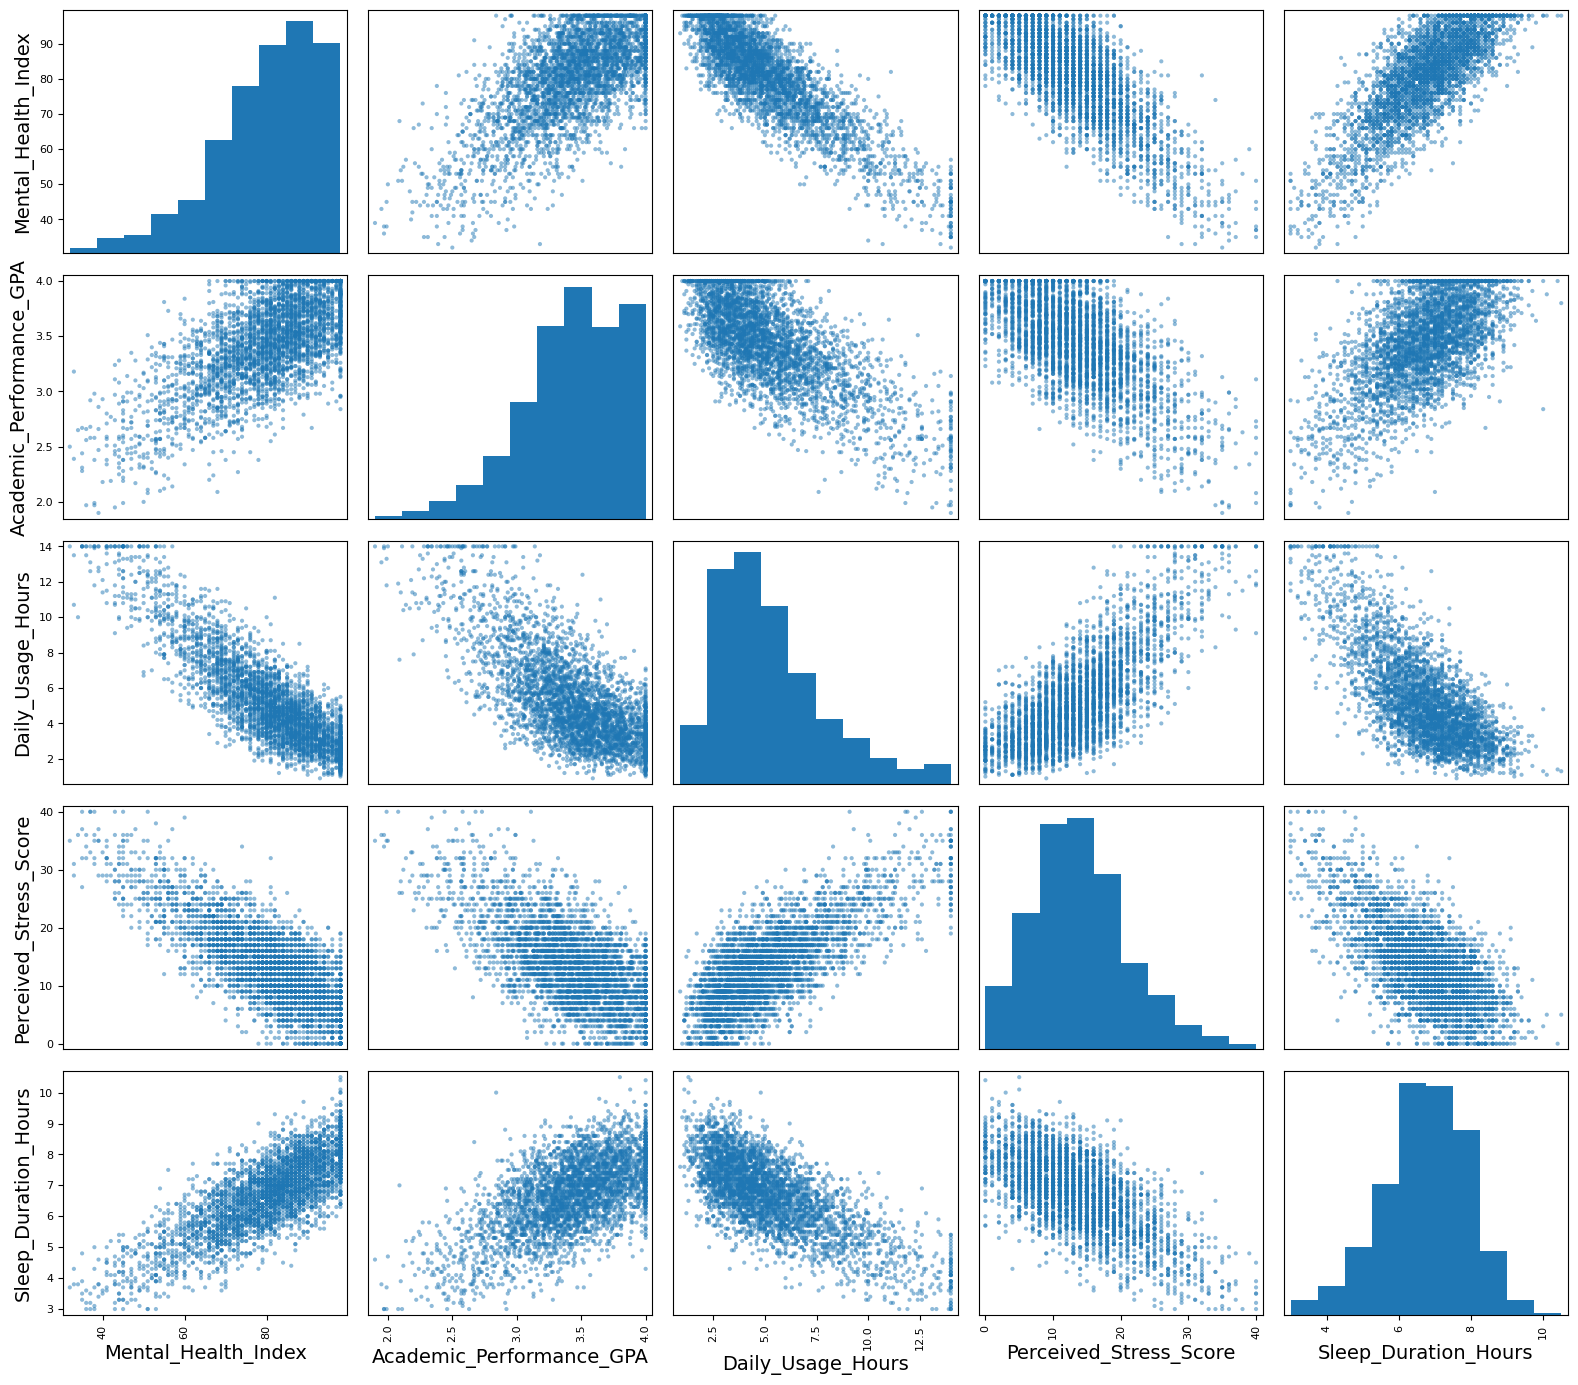

In [21]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

scatter_matrix(
    student_train[[
    "Mental_Health_Index",
    "Academic_Performance_GPA",
    "Daily_Usage_Hours",
    "Perceived_Stress_Score",
    "Sleep_Duration_Hours"
]],
    figsize=(16, 14),
    diagonal="hist"
)

plt.tight_layout()
plt.show()

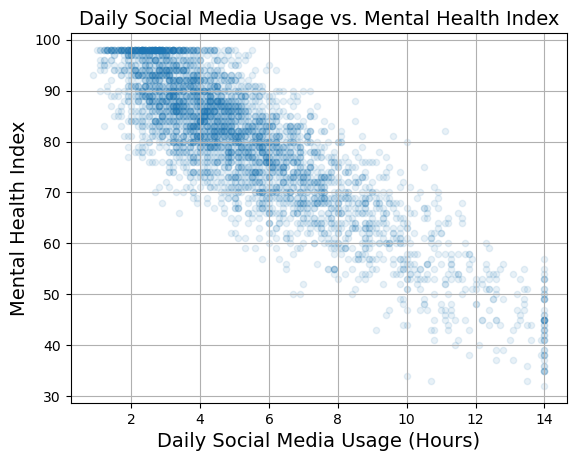

In [22]:
student_train.plot(
    kind="scatter",
    x="Daily_Usage_Hours",
    y="Mental_Health_Index",
    alpha=0.1,
    grid=True
)

plt.xlabel("Daily Social Media Usage (Hours)")
plt.ylabel("Mental Health Index")
plt.title("Daily Social Media Usage vs. Mental Health Index")
plt.show()

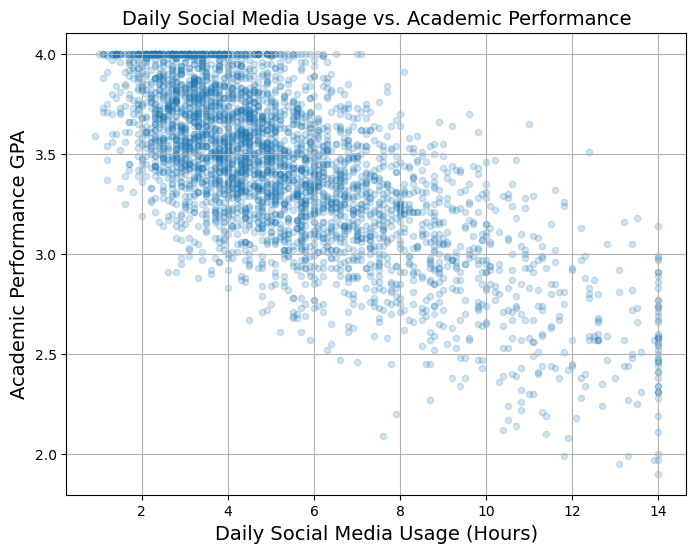

In [23]:
student_train.plot(
    kind="scatter",
    x="Daily_Usage_Hours",
    y="Academic_Performance_GPA",
    alpha=0.2,
    grid=True,
    figsize=(8, 6)
)

plt.xlabel("Daily Social Media Usage (Hours)")
plt.ylabel("Academic Performance GPA")
plt.title("Daily Social Media Usage vs. Academic Performance")
plt.show()

#### EDA Findings

Daily social media usage has a strong negative association with Mental Health Index (r ≈ -0.85), while sleep duration has a strong positive association (r ≈ 0.78). Perceived stress is also strongly negatively associated with Mental Health Index (r ≈ -0.78).

The scatter plots show a negative relationship between daily social media usage and both Mental Health Index and Academic Performance GPA. These relationships are associations observed in the data and should not be interpreted as causal effects.

### Experimenting with Attribute Combinations

In [24]:
student_train["Total_Social_Media_Hours"] = (
    student_train["Daily_Usage_Hours"]
    + student_train["Weekend_Extra_Hours"]
)

In [25]:
corr_matrix = student_train.corr(numeric_only=True)

corr_matrix[
    [
        "Mental_Health_Index",
        "Academic_Performance_GPA"
    ]
].loc["Total_Social_Media_Hours"]

Mental_Health_Index        -0.826649
Academic_Performance_GPA   -0.688541
Name: Total_Social_Media_Hours, dtype: float64

## 4. Prepare the Data for Machine Learning Algorithms

In [26]:
x = student_train.drop(
    ["Mental_Health_Index",
     "Student_ID",
     "Academic_Performance_GPA",
     "Overall_Impact"],
    axis=1
)
y = student_train["Mental_Health_Index"].copy()

#### Feature Selection: 

Before preprocessing, Student_ID, Academic_Performance_GPA, and Overall_Impact were excluded from the predictive features. Reasons are as follows: 

Student_ID is a unique identifier and does not provide meaningful predictive information. 

Overall_Impact is a derived summary indicator and may contain outcome-related information, creating a potential risk of information leakage. 

Academic_Performance_GPA was excluded to keep the predictive task focused on social media use, sleep, stress, and demographic characteristics as predictors of mental health.

### Data Cleaning

In [27]:
null_rows_idx = x.isnull().any(axis=1)
x.loc[null_rows_idx].head()

,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Total_Social_Media_Hours
2555,17,Female,High School,Instagram,1.9,2.6,Laptop/PC,8.5,4,True,Rarely,NaN,4.5
1240,26,Male,Postgraduate,YouTube,9.2,1.5,Smartphone,4.8,1,True,Sometimes,NaN,10.7
3111,19,Male,Undergraduate,X (Twitter),9.2,3.1,Laptop/PC,6.0,2,True,Sometimes,NaN,12.3
4230,18,Female,Undergraduate,Instagram,3.5,1.4,Smartphone,8.8,3,True,Always,NaN,4.9
1021,24,Male,Postgraduate,YouTube,4.8,3.1,Laptop/PC,10.0,5,False,Sometimes,NaN,7.9


In [ ]:
# Simple imputer
student_clean = x.copy()

stress_median = student_clean["Perceived_Stress_Score"].median()

student_clean["Perceived_Stress_Score"] = (
    student_clean["Perceived_Stress_Score"]
    .fillna(stress_median)
)

student_clean.loc[null_rows_idx].head()

,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Total_Social_Media_Hours
2555,17,Female,High School,Instagram,1.9,2.6,Laptop/PC,8.5,4,True,Rarely,13.0,4.5
1240,26,Male,Postgraduate,YouTube,9.2,1.5,Smartphone,4.8,1,True,Sometimes,13.0,10.7
3111,19,Male,Undergraduate,X (Twitter),9.2,3.1,Laptop/PC,6.0,2,True,Sometimes,13.0,12.3
4230,18,Female,Undergraduate,Instagram,3.5,1.4,Smartphone,8.8,3,True,Always,13.0,4.9
1021,24,Male,Postgraduate,YouTube,4.8,3.1,Laptop/PC,10.0,5,False,Sometimes,13.0,7.9


Academic_Performance_GPA also contains missing values, but this variable was excluded from the predictive features because it is a separate outcome measure.

Excluding it also keeps the model focused on social media use, sleep, stress, and demographic characteristics when predicting Mental Health Index.

In [ ]:
# Outlier detection using Isolation Forest
from sklearn.ensemble import IsolationForest

student_num = student_clean.select_dtypes(include=["number"])
isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(student_num)

In [30]:
print("Number of outliers:", (outlier_pred == -1).sum())
print(
    "Percentage of outliers:",
    round((outlier_pred == -1).mean() * 100, 2),
    "%"
)

Number of outliers: 670
Percentage of outliers: 18.61 %


In [31]:
# Inspect the potential outliers
outlier_rows = student_clean.loc[outlier_pred == -1]

outlier_rows.head()

,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Total_Social_Media_Hours
510,18,Female,Undergraduate,LinkedIn,1.8,1.2,Smartphone,8.8,5,True,Rarely,10.0,3.0
1016,22,Male,Undergraduate,YouTube,2.2,1.2,Smartphone,8.2,5,True,Rarely,5.0,3.4
2521,19,Male,Undergraduate,Reddit,2.9,3.0,Smartphone,8.6,5,False,Sometimes,13.0,5.9
618,19,Male,Undergraduate,Instagram,11.7,0.6,Smartphone,4.7,1,False,Frequently,17.0,12.3
402,20,Female,Undergraduate,Instagram,4.1,0.0,Smartphone,6.7,4,False,Rarely,16.0,4.1


In [32]:
outlier_rows.describe()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Perceived_Stress_Score,Total_Social_Media_Hours
count,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000
mean,19.268657,7.273731,1.751791,6.140597,2.234328,17.589552,9.025522
std,2.710673,4.279362,0.906803,1.827753,1.473336,10.851913,4.426867
min,15.000000,0.900000,0.000000,3.000000,1.000000,0.000000,1.700000
25%,17.000000,2.700000,1.100000,4.500000,1.000000,8.000000,4.400000
50%,19.000000,7.900000,1.800000,5.900000,1.000000,19.000000,9.900000
75%,21.000000,10.900000,2.400000,7.800000,4.000000,27.000000,12.500000
max,26.000000,14.000000,4.100000,10.500000,5.000000,40.000000,17.400000


In [33]:
normal_rows = student_clean.loc[outlier_pred == 1]

normal_rows.head()

,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Total_Social_Media_Hours
3329,18,Male,Undergraduate,YouTube,2.3,2.7,Smartphone,6.4,3,False,Sometimes,10.0,5.0
2963,20,Female,Undergraduate,LinkedIn,3.4,1.8,Smartphone,7.6,5,True,Frequently,12.0,5.2
53,22,Male,Postgraduate,YouTube,4.9,2.6,Laptop/PC,7.8,3,False,Sometimes,9.0,7.5
1693,17,Male,High School,Instagram,8.5,2.0,Smartphone,5.6,1,True,Sometimes,18.0,10.5
2366,19,Male,Undergraduate,YouTube,2.3,2.6,Smartphone,9.0,3,False,Rarely,7.0,4.9


Outlier Detection: 
Isolation Forest was used to identify potential outliers among the numerical features. The flagged observations were retained because the detected values fell within plausible ranges and did not indicate obvious data-entry errors.

### Handling Text and Categorical Attributes

In [34]:
student_cat = student_clean[
    [
        "Gender",
        "Academic_Level",
        "Primary_Platform",
        "Device_Type",
        "Late_Night_Usage",
        "Social_Comparison_Frequency"
    ]
]

student_cat.head()

,Gender,Academic_Level,Primary_Platform,Device_Type,Late_Night_Usage,Social_Comparison_Frequency
3329,Male,Undergraduate,YouTube,Smartphone,False,Sometimes
2963,Female,Undergraduate,LinkedIn,Smartphone,True,Frequently
53,Male,Postgraduate,YouTube,Laptop/PC,False,Sometimes
510,Female,Undergraduate,LinkedIn,Smartphone,True,Rarely
1693,Male,High School,Instagram,Smartphone,True,Sometimes


In [ ]:
# One hot encoding
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False)
student_cat_1hot = cat_encoder.fit_transform(student_cat)
student_cat_1hot

array([[0., 1., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.]], shape=(3600, 24))

In [36]:
cat_encoder.categories_

[array(['Female', 'Male', 'Non-Binary', 'Prefer not to say'], dtype=object),
 array(['High School', 'Postgraduate', 'Undergraduate'], dtype=object),
 array(['Instagram', 'LinkedIn', 'Reddit', 'Snapchat', 'TikTok',
        'X (Twitter)', 'YouTube'], dtype=object),
 array(['Laptop/PC', 'Smartphone', 'Tablet'], dtype=object),
 array([False,  True]),
 array(['Always', 'Frequently', 'Never', 'Rarely', 'Sometimes'],
       dtype=object)]

In [37]:
cat_encoder.get_feature_names_out()

array(['Gender_Female', 'Gender_Male', 'Gender_Non-Binary',
       'Gender_Prefer not to say', 'Academic_Level_High School',
       'Academic_Level_Postgraduate', 'Academic_Level_Undergraduate',
       'Primary_Platform_Instagram', 'Primary_Platform_LinkedIn',
       'Primary_Platform_Reddit', 'Primary_Platform_Snapchat',
       'Primary_Platform_TikTok', 'Primary_Platform_X (Twitter)',
       'Primary_Platform_YouTube', 'Device_Type_Laptop/PC',
       'Device_Type_Smartphone', 'Device_Type_Tablet',
       'Late_Night_Usage_False', 'Late_Night_Usage_True',
       'Social_Comparison_Frequency_Always',
       'Social_Comparison_Frequency_Frequently',
       'Social_Comparison_Frequency_Never',
       'Social_Comparison_Frequency_Rarely',
       'Social_Comparison_Frequency_Sometimes'], dtype=object)

In [38]:
student_cat_output = pd.DataFrame(
    student_cat_1hot,
    columns=cat_encoder.get_feature_names_out(student_cat.columns),
    index=student_cat.index
)
student_cat_output.head()

,Gender_Female,Gender_Male,Gender_Non-Binary,Gender_Prefer not to say,Academic_Level_High School,Academic_Level_Postgraduate,Academic_Level_Undergraduate,Primary_Platform_Instagram,Primary_Platform_LinkedIn,Primary_Platform_Reddit,...,Device_Type_Laptop/PC,Device_Type_Smartphone,Device_Type_Tablet,Late_Night_Usage_False,Late_Night_Usage_True,Social_Comparison_Frequency_Always,Social_Comparison_Frequency_Frequently,Social_Comparison_Frequency_Never,Social_Comparison_Frequency_Rarely,Social_Comparison_Frequency_Sometimes
3329,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2963,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
53,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
510,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1693,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### Feature Scaling

In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
student_num_std_scaled = std_scaler.fit_transform(student_num)

In [40]:
student_num_std_scaled[:5]

array([[-0.35033186, -1.13859134,  1.29999736, -0.24792694,  0.50706564,
        -0.49802679, -0.77148185],
       [ 0.64903002, -0.72118128,  0.0077376 ,  0.75755971,  2.45108726,
        -0.21714062, -0.69783691],
       [ 1.6483919 , -0.15198575,  1.15641294,  0.92514082,  0.50706564,
        -0.63846988,  0.14907985],
       [-0.35033186, -1.32832318, -0.8537689 ,  1.76304636,  2.45108726,
        -0.49802679, -1.50793121],
       [-0.8500128 ,  1.21408353,  0.29490644, -0.91825138, -1.43695598,
         0.62551791,  1.2537539 ]])

### Transformation Pipelines

In [41]:
x = student_train.drop(
    [
        "Mental_Health_Index",
        "Student_ID",
        "Academic_Performance_GPA",
        "Overall_Impact"
    ],
    axis=1
)

y = student_train["Mental_Health_Index"].copy()

In [42]:
num_attribs = [
    "Age",
    "Daily_Usage_Hours",
    "Weekend_Extra_Hours",
    "Sleep_Duration_Hours",
    "Sleep_Quality_Score",
    "Perceived_Stress_Score",
    "Total_Social_Media_Hours"
]

cat_attribs = [
    "Gender",
    "Academic_Level",
    "Primary_Platform",
    "Device_Type",
    "Late_Night_Usage",
    "Social_Comparison_Frequency"
]

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())
])

In [44]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    ))
])

In [45]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

In [46]:
student_prepared = preprocessing.fit_transform(x)

student_prepared.shape

(3600, 25)

In [47]:
preprocessing.get_feature_names_out()

array(['num__Age', 'num__Daily_Usage_Hours', 'num__Weekend_Extra_Hours',
       'num__Sleep_Duration_Hours', 'num__Sleep_Quality_Score',
       'num__Perceived_Stress_Score', 'num__Total_Social_Media_Hours',
       'cat__Gender_Male', 'cat__Gender_Non-Binary',
       'cat__Gender_Prefer not to say',
       'cat__Academic_Level_Postgraduate',
       'cat__Academic_Level_Undergraduate',
       'cat__Primary_Platform_LinkedIn', 'cat__Primary_Platform_Reddit',
       'cat__Primary_Platform_Snapchat', 'cat__Primary_Platform_TikTok',
       'cat__Primary_Platform_X (Twitter)',
       'cat__Primary_Platform_YouTube', 'cat__Device_Type_Smartphone',
       'cat__Device_Type_Tablet', 'cat__Late_Night_Usage_True',
       'cat__Social_Comparison_Frequency_Frequently',
       'cat__Social_Comparison_Frequency_Never',
       'cat__Social_Comparison_Frequency_Rarely',
       'cat__Social_Comparison_Frequency_Sometimes'], dtype=object)

## 5. Select and Train a Model

### Training and Evaluating on the Training Set

#### Modeling Strategy

Three regression models were explored: 

Linear Regression, Decision Tree Regression, and Random Forest Regression. 

Cross-validation was used to compare model generalization performance. Random Forest was then further tuned using Grid Search

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(x, y)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
student_predictions = lin_reg.predict(x)

student_predictions[:5]

array([87.00441666, 87.56781692, 85.45770241, 95.65960713, 67.52434008])

In [50]:
y.iloc[:5].values

array([98, 88, 76, 90, 72])

In [51]:
error_ratios = (
    student_predictions[:5] / y.iloc[:5].values - 1
)

print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-11.2%, -0.5%, 12.4%, 6.3%, -6.2%


In [52]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(
    y,
    student_predictions
)

lin_rmse

5.722609181427448

The model's predictions differ from the actual Mental Health Index values by about 5.7 index points on average, with larger errors receiving greater weight.

In [53]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(
    preprocessing,
    DecisionTreeRegressor(random_state=42)
)

tree_reg.fit(x, y)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
student_tree_predictions = tree_reg.predict(x)

tree_rmse = root_mean_squared_error(
    y,
    student_tree_predictions
)

tree_rmse

0.0

The Decision Tree achieved a training RMSE of 0.0, indicating that it fits the training data almost perfectly. 

However, this extremely low training error may indicate overfitting, we still need to evaluate its performance.

### Better Evaluation Using Cross-Validation

In [55]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(
    tree_reg,
    x,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)

In [56]:
pd.Series(tree_rmses).describe()

count    10.000000
mean      8.374897
std       0.285960
min       7.939353
25%       8.119687
50%       8.438652
75%       8.571712
max       8.804513
dtype: float64

In [57]:
lin_rmses = -cross_val_score(
    lin_reg,
    x,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)

pd.Series(lin_rmses).describe()

count    10.000000
mean      5.768892
std       0.155927
min       5.466115
25%       5.695332
50%       5.788995
75%       5.832030
max       6.011286
dtype: float64

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(
    preprocessing,
    RandomForestRegressor(random_state=42)
)

In [104]:
forest_reg.fit(x, y)

student_forest_predictions = forest_reg.predict(x)

forest_rmse = root_mean_squared_error(
    y,
    student_forest_predictions
)

forest_rmse

2.2690999622953787

In [106]:
forest_rmses = -cross_val_score(
    forest_reg,
    x,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)
pd.Series(forest_rmses).describe()

count    10.000000
mean      5.979596
std       0.146500
min       5.699244
25%       5.886317
50%       6.017813
75%       6.072341
max       6.174081
dtype: float64

#### Cross-Validation Results

As we can see, Linear Regression has the lowest cross-validation RMSE (5.77), followed by Random Forest (5.98). Decision Tree had the highest RMSE (8.37), suggesting strong overfitting. 

Overall, Linear Regression showed the most consistent performance among the models currently.

## 6. Fine-Tune Your Model

### Grid Search

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

In [62]:
param_grid = {
    "random_forest__max_features": [0.5, 0.8, 1.0],
    "random_forest__max_depth": [None, 10, 20]
}

In [82]:
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error"
)

grid_search.fit(x, y)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'random_forest__max_depth': [None, 10, ...], 'random_forest__max_features': [0.5, 0.8, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [84]:
print(
    [
        key for key in full_pipeline.get_params().keys()
        if "random_forest" in key
    ]
)

['random_forest', 'random_forest__bootstrap', 'random_forest__ccp_alpha', 'random_forest__criterion', 'random_forest__max_depth', 'random_forest__max_features', 'random_forest__max_leaf_nodes', 'random_forest__max_samples', 'random_forest__min_impurity_decrease', 'random_forest__min_samples_leaf', 'random_forest__min_samples_split', 'random_forest__min_weight_fraction_leaf', 'random_forest__monotonic_cst', 'random_forest__n_estimators', 'random_forest__n_jobs', 'random_forest__oob_score', 'random_forest__random_state', 'random_forest__verbose', 'random_forest__warm_start']


In [85]:
grid_search.best_params_

{'random_forest__max_depth': 10, 'random_forest__max_features': 0.5}

In [86]:
grid_search.best_estimator_

,steps,"[('preprocessing', ...), ('random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [87]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results[
    [
        "param_random_forest__max_features",
        "param_random_forest__max_depth",
        "mean_test_score"
    ]
].sort_values("mean_test_score", ascending=False)

,param_random_forest__max_features,param_random_forest__max_depth,mean_test_score
3,0.5,10,-5.884217
5,1.0,10,-5.926804
4,0.8,10,-5.926874
6,0.5,20,-5.941351
0,0.5,None,-5.949168
1,0.8,None,-5.975322
2,1.0,None,-5.979596
7,0.8,20,-5.984391
8,1.0,20,-5.985749


In [107]:
cv_results["mean_test_rmse"] = -cv_results["mean_test_score"]

cv_results[
    [
        "param_random_forest__max_features",
        "param_random_forest__max_depth",
        "mean_test_rmse"
    ]
].sort_values("mean_test_rmse")

,param_random_forest__max_features,param_random_forest__max_depth,mean_test_rmse
3,0.5,10,5.884217
5,1.0,10,5.926804
4,0.8,10,5.926874
6,0.5,20,5.941351
0,0.5,None,5.949168
1,0.8,None,5.975322
2,1.0,None,5.979596
7,0.8,20,5.984391
8,1.0,20,5.985749


#### Grid Search

Different parameter combinations were evaluated using cross-validation. The best combination was `max_features = 0.5` and `max_depth = 10`, with a cross-validation RMSE of approximately 5.88.

### Analyze the Best Models and Their Errors

In [89]:
tuned_rf_model = grid_search.best_estimator_

feature_importances = (
    tuned_rf_model["random_forest"].feature_importances_
)

feature_importances.round(2)

array([0.01, 0.41, 0.02, 0.18, 0.02, 0.09, 0.24, 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  ,
       0.  , 0.  , 0.  ])

In [90]:
sorted(
    zip(
        feature_importances,
        tuned_rf_model["preprocessing"].get_feature_names_out()
    ),
    reverse=True
)

[(np.float64(0.40762462189979976), 'num__Daily_Usage_Hours'),
 (np.float64(0.2409315648612109), 'num__Total_Social_Media_Hours'),
 (np.float64(0.1849256758997418), 'num__Sleep_Duration_Hours'),
 (np.float64(0.08578470071945113), 'num__Perceived_Stress_Score'),
 (np.float64(0.021526416838951467), 'num__Sleep_Quality_Score'),
 (np.float64(0.01658333829855822), 'num__Weekend_Extra_Hours'),
 (np.float64(0.009766347325001734), 'num__Age'),
 (np.float64(0.005154889987185112), 'cat__Late_Night_Usage_True'),
 (np.float64(0.002625057614326851), 'cat__Gender_Male'),
 (np.float64(0.002484204867232759), 'cat__Primary_Platform_TikTok'),
 (np.float64(0.0022533545515517886),
  'cat__Social_Comparison_Frequency_Sometimes'),
 (np.float64(0.0022334666846297434), 'cat__Academic_Level_Undergraduate'),
 (np.float64(0.0020536788410229385), 'cat__Primary_Platform_YouTube'),
 (np.float64(0.0020276069319926037), 'cat__Primary_Platform_Snapchat'),
 (np.float64(0.001937262442659191), 'cat__Device_Type_Smartphone

#### Feature Importance

The tuned Random Forest placed the greatest predictive importance on Daily Usage Hours, Total Social Media Hours, Sleep Duration, and Perceived Stress. These values describe the model's predictive behavior.

### Evaluate My System on the Test Set

In [91]:
student_test = test_set.copy()

In [92]:
student_test["Total_Social_Media_Hours"] = (
    student_test["Daily_Usage_Hours"]
    + student_test["Weekend_Extra_Hours"]
)

In [93]:
test_x = student_test.drop(
    [
        "Mental_Health_Index",
        "Student_ID",
        "Academic_Performance_GPA",
        "Overall_Impact"
    ],
    axis=1
)

test_y = student_test["Mental_Health_Index"].copy()

In [94]:
# Tuned Random Forest
tuned_rf_predictions = tuned_rf_model.predict(test_x)

In [95]:
tuned_rf_rmse = root_mean_squared_error(
    test_y,
    tuned_rf_predictions
)

tuned_rf_rmse

6.081779135977053

In [96]:
tuned_rf_train_predictions = tuned_rf_model.predict(x)

tuned_rf_train_rmse = root_mean_squared_error(
    y,
    tuned_rf_train_predictions
)

tuned_rf_train_rmse

4.009568290638125

In [97]:
-grid_search.best_score_

np.float64(5.884217420937654)

In [98]:
# Linear Regression Test RMSE
linear_test_predictions = lin_reg.predict(test_x)

linear_test_rmse = root_mean_squared_error(
    test_y,
    linear_test_predictions
)

linear_test_rmse

5.931975093896766

In [99]:
# Decision Tree Test RMSE
tree_test_predictions = tree_reg.predict(test_x)

tree_test_rmse = root_mean_squared_error(
    test_y,
    tree_test_predictions
)

tree_test_rmse

8.849105416180025

In [100]:
# Untuned Random Forest Test RMSE
forest_test_predictions = forest_reg.predict(test_x)

forest_test_rmse = root_mean_squared_error(
    test_y,
    forest_test_predictions
)

forest_test_rmse

6.24068658081785

### Final Model Evaluation

| Model | Training RMSE | Cross-Validation RMSE | Test RMSE |
|---|---:|---:|---:|
| Linear Regression | 5.72 | 5.77 | 5.93 |
| Decision Tree | 0.00 | 8.37 | 8.85 |
| Untuned Random Forest | 2.27 | 5.98 | 6.24 |
| Tuned Random Forest | 4.01 | 5.88 | 6.08 |

### Conclusion

We can see that Linear Regression performed the best on this dataset. Its cross-validation RMSE is 5.77 and test RMSE is 5.93. The training and test RMSE were also relatively close, suggesting that the model did not show strong overfitting.

For other models, the Decision Tree clearly overfit the training data. The Random Forest models performed better but it didn't outperform Linear Regression. Therefore, based on the cross-validation and test results, Linear Regression was selected as the final model for predicting Mental Health Index.